# LSTM - Dataset (sexism-detection-english-text)

In [1]:
!pip install -q tensorflow scikit-learn matplotlib seaborn wordcloud

In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import pickle
import os

os.makedirs('/content/models/lstm_ddet', exist_ok=True)
np.random.seed(42)
tf.random.set_seed(42)

In [3]:
train_df = pd.read_csv('/content/train.csv')
dev_df = pd.read_csv('/content/dev.csv')
test_df = pd.read_csv('/content/test.csv')

for d in [train_df, dev_df, test_df]:
    d['text'] = d['text'].str.lower()

print('Train:', train_df['label'].value_counts().to_dict())
print('Dev:', dev_df['label'].value_counts().to_dict())
print('Test:', test_df['label'].value_counts().to_dict())

Train: {0: 10602, 1: 3398}
Dev: {0: 1514, 1: 486}
Test: {0: 3030, 1: 970}


In [4]:
vocab_size = 10000
embedding_dim = 100
max_length = 100

tokenizer = Tokenizer(num_words=vocab_size, oov_token='<OOV>')
tokenizer.fit_on_texts(train_df['text'].astype(str))

with open('/content/models/lstm_ddet/tokenizer.pickle', 'wb') as f:
    pickle.dump(tokenizer, f, protocol=pickle.HIGHEST_PROTOCOL)

def pad(df_col):
    seqs = tokenizer.texts_to_sequences(df_col.astype(str))
    return pad_sequences(seqs, maxlen=max_length, padding='post', truncating='post')

X_train = pad(train_df['text']); y_train = train_df['label'].values
X_dev = pad(dev_df['text']); y_dev = dev_df['label'].values
X_test = pad(test_df['text']); y_test = test_df['label'].values

classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight = dict(zip(classes, weights))
print('Class weights:', class_weight)

Class weights: {np.int64(0): np.float64(0.6602527824938691), np.int64(1): np.float64(2.0600353148911124)}


In [5]:
model = Sequential([
    Embedding(vocab_size, embedding_dim, input_length=max_length),
    SpatialDropout1D(0.3),
    Bidirectional(LSTM(64, return_sequences=True, kernel_regularizer=l2(0.001))),
    Dropout(0.5),
    Bidirectional(LSTM(32, kernel_regularizer=l2(0.001))),
    Dropout(0.5),
    Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-5, verbose=1)

history = model.fit(
    X_train, y_train,
    epochs=6,
    batch_size=64,
    validation_data=(X_dev, y_dev),
    class_weight=class_weight,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

model.save('/content/models/lstm_ddet/sexism_model.h5')

Epoch 1/6
219/219 ━━━━━━━━━━━━━━━━━━━━ 99s 331ms/step - accuracy: 0.6200 - loss: 1.1734 - val_accuracy: 0.4935 - val_loss: 1.0811 - learning_rate: 1.0000e-04
Epoch 2/6
219/219 ━━━━━━━━━━━━━━━━━━━━ 83s 337ms/step - accuracy: 0.6515 - loss: 1.0102 - val_accuracy: 0.6600 - val_loss: 0.9266 - learning_rate: 1.0000e-04
Epoch 3/6
219/219 ━━━━━━━━━━━━━━━━━━━━ 81s 335ms/step - accuracy: 0.6489 - loss: 0.8895 - val_accuracy: 0.5935 - val_loss: 0.8432 - learning_rate: 1.0000e-04
Epoch 4/6
219/219 ━━━━━━━━━━━━━━━━━━━━ 82s 334ms/step - accuracy: 0.7381 - loss: 0.7104 - val_accuracy: 0.7230 - val_loss: 0.6872 - learning_rate: 1.0000e-04
Epoch 5/6
219/219 ━━━━━━━━━━━━━━━━━━━━ 81s 330ms/step - accuracy: 0.8115 - loss: 0.5605 - val_accuracy: 0.7690 - val_loss: 0.6204 - learning_rate: 1.0000e-04
Epoch 6/6
219/219 ━━━━━━━━━━━━━━━━━━━━ 72s 330ms/step - accuracy: 0.8474 - loss: 0.4761 - val_accuracy: 0.7720 - val_loss: 0.6096 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epo

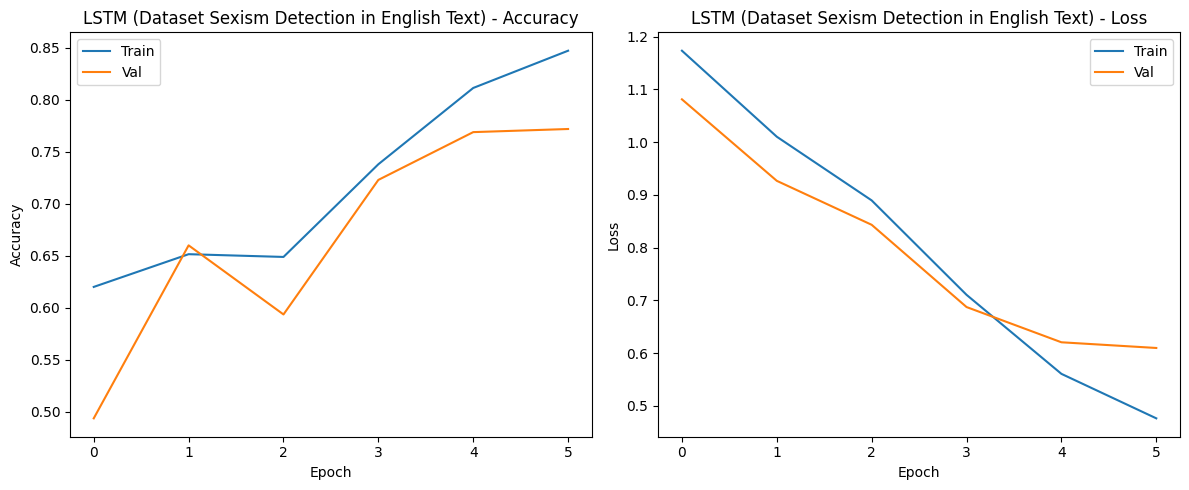

In [7]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('LSTM (Dataset Sexism Detection in English Text) - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('LSTM (Dataset Sexism Detection in English Text) - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.savefig('/content/models/lstm_ddet/training_history.png', dpi=150)
plt.show()

125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step


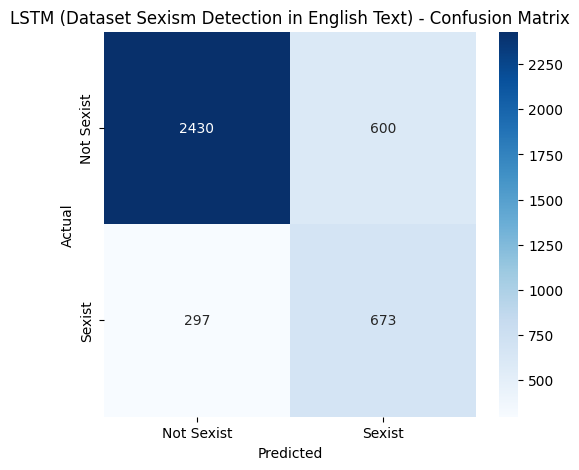

              precision    recall  f1-score   support

  Not Sexist       0.89      0.80      0.84      3030
      Sexist       0.53      0.69      0.60       970

    accuracy                           0.78      4000
   macro avg       0.71      0.75      0.72      4000
weighted avg       0.80      0.78      0.78      4000



In [8]:
y_pred = (model.predict(X_test) > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Sexist', 'Sexist'], yticklabels=['Not Sexist', 'Sexist'])
plt.title('LSTM (Dataset Sexism Detection in English Text) - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('/content/models/lstm_ddet/confusion_matrix.png', dpi=150)
plt.show()

report = classification_report(y_test, y_pred, target_names=['Not Sexist', 'Sexist'])
print(report)

with open('/content/models/lstm_ddet/metrics.txt', 'w') as f:
    f.write(report)
    f.write('\nConfusion Matrix:\n')
    f.write(str(cm))

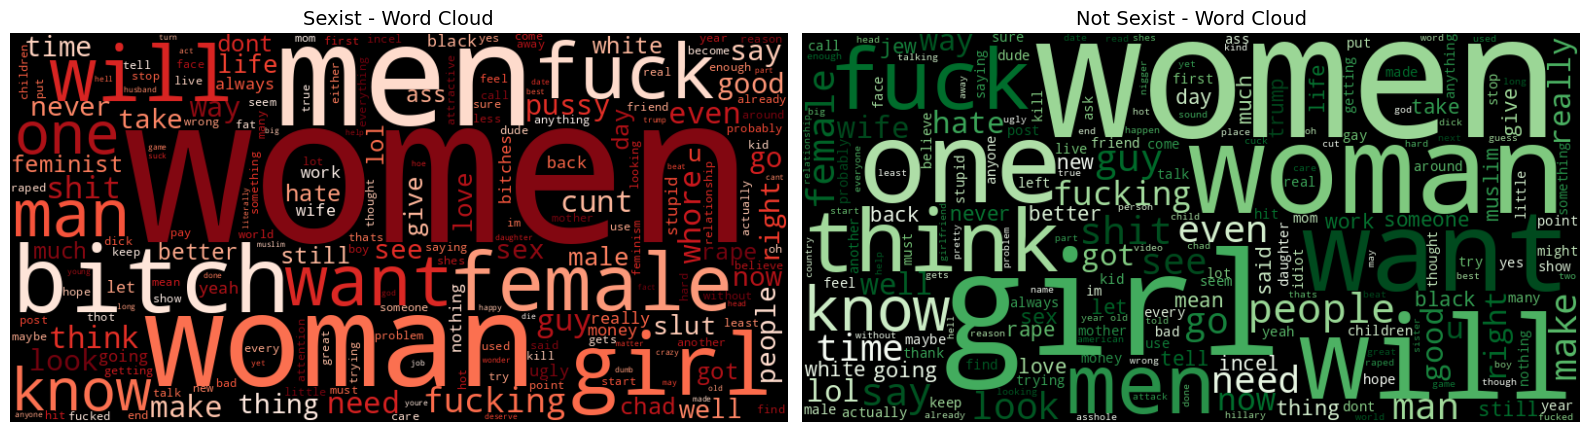

In [9]:
all_df = pd.concat([train_df, dev_df, test_df])
sexist_text = ' '.join(all_df[all_df['label'] == 1]['text'].tolist())
clean_text = ' '.join(all_df[all_df['label'] == 0]['text'].tolist())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(sexist_text), interpolation='bilinear')
axes[0].set_title('Sexist - Word Cloud', fontsize=14)
axes[0].axis('off')
axes[1].imshow(WordCloud(width=800, height=400, background_color='black', colormap='Greens').generate(clean_text), interpolation='bilinear')
axes[1].set_title('Not Sexist - Word Cloud', fontsize=14)
axes[1].axis('off')
plt.tight_layout()
plt.savefig('/content/models/lstm_ddet/wordclouds.png', dpi=150)
plt.show()

In [10]:
import shutil
shutil.make_archive('/content/lstm_ddet_results', 'zip', '/content/models/lstm_ddet')

'/content/lstm_ddet_results.zip'